In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from minisom import MiniSom
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# Feature definitions
behavioral_features = [
    'income', 'frq', 'per_net_purchase', 'spent_online'
]

preference_features = [
    'clothes', 'kitchen', 'small_appliances',
    'toys', 'house_keeping'
]

metric_features = behavioral_features + preference_features

In [2]:
df = pd.read_csv('df_cleaned.csv')

## Train SOM

Grid size rule of thumb:

5
×
Underroot n
	​


For ~8800 customers → ~ 5×√8800 ≈ 470 → 20×25 ≈ 500 neurons is reasonable.

In [3]:
data =  df[metric_features]

In [7]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [11]:
data = data.to_numpy()

In [12]:
M = 20
N = 30

sm = MiniSom(
    x=M,
    y=N,
    input_len=len(metric_features),
    sigma=1.8,
    learning_rate=0.5,
    neighborhood_function='gaussian',
    activation_distance='euclidean',
    random_seed=42
)

sm.random_weights_init(data)

qe_before = sm.quantization_error(data)
te_before = sm.topographic_error(data)

print("Starting QE:", round(qe_before,4))
print("Starting TE:", round(te_before,4))

sm.train_batch(data, 500_000)

qe_after = sm.quantization_error(data)
te_after = sm.topographic_error(data)

print("Ending QE:", round(qe_after,4))
print("Ending TE:", round(te_after,4))

Starting QE: 0.8356
Starting TE: 0.9889
Ending QE: 0.7974
Ending TE: 0.1586


In [13]:
weights = sm.get_weights()
print("SOM Grid Shape:", weights.shape)

SOM Grid Shape: (20, 30, 9)


## U-Matrix (Cluster Boundaries)

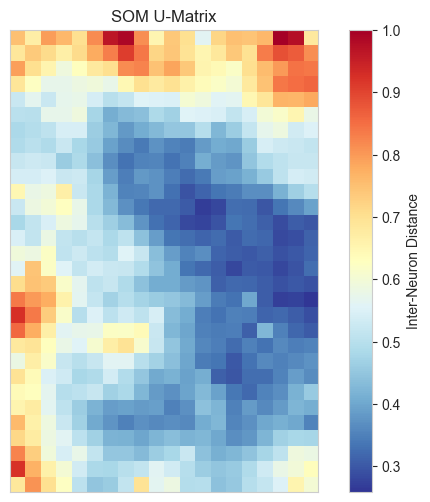

In [14]:
umatrix = sm.distance_map(scaling='mean')

plt.figure(figsize=(8,6))
plt.imshow(umatrix.T, cmap="RdYlBu_r")
plt.colorbar(label="Inter-Neuron Distance")
plt.title("SOM U-Matrix")
plt.xticks([])
plt.yticks([])
plt.show()

## Hit Map (Customer Density)

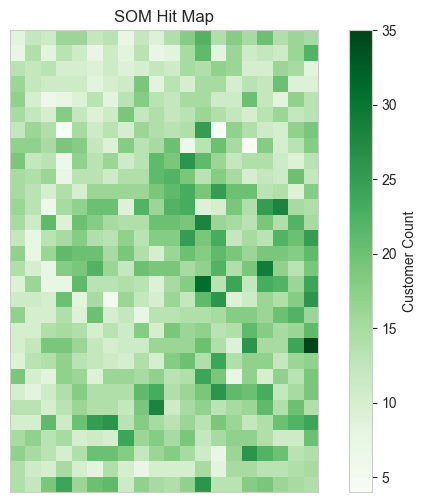

Average customers per unit: 14.9
Range: 4 to 35


In [15]:
hitsmatrix = sm.activation_response(data)

plt.figure(figsize=(8,6))
plt.imshow(hitsmatrix.T, cmap="Greens")
plt.colorbar(label="Customer Count")
plt.title("SOM Hit Map")
plt.xticks([])
plt.yticks([])
plt.show()

print("Average customers per unit:", round(hitsmatrix.mean(),1))
print("Range:", int(hitsmatrix.min()), "to", int(hitsmatrix.max()))

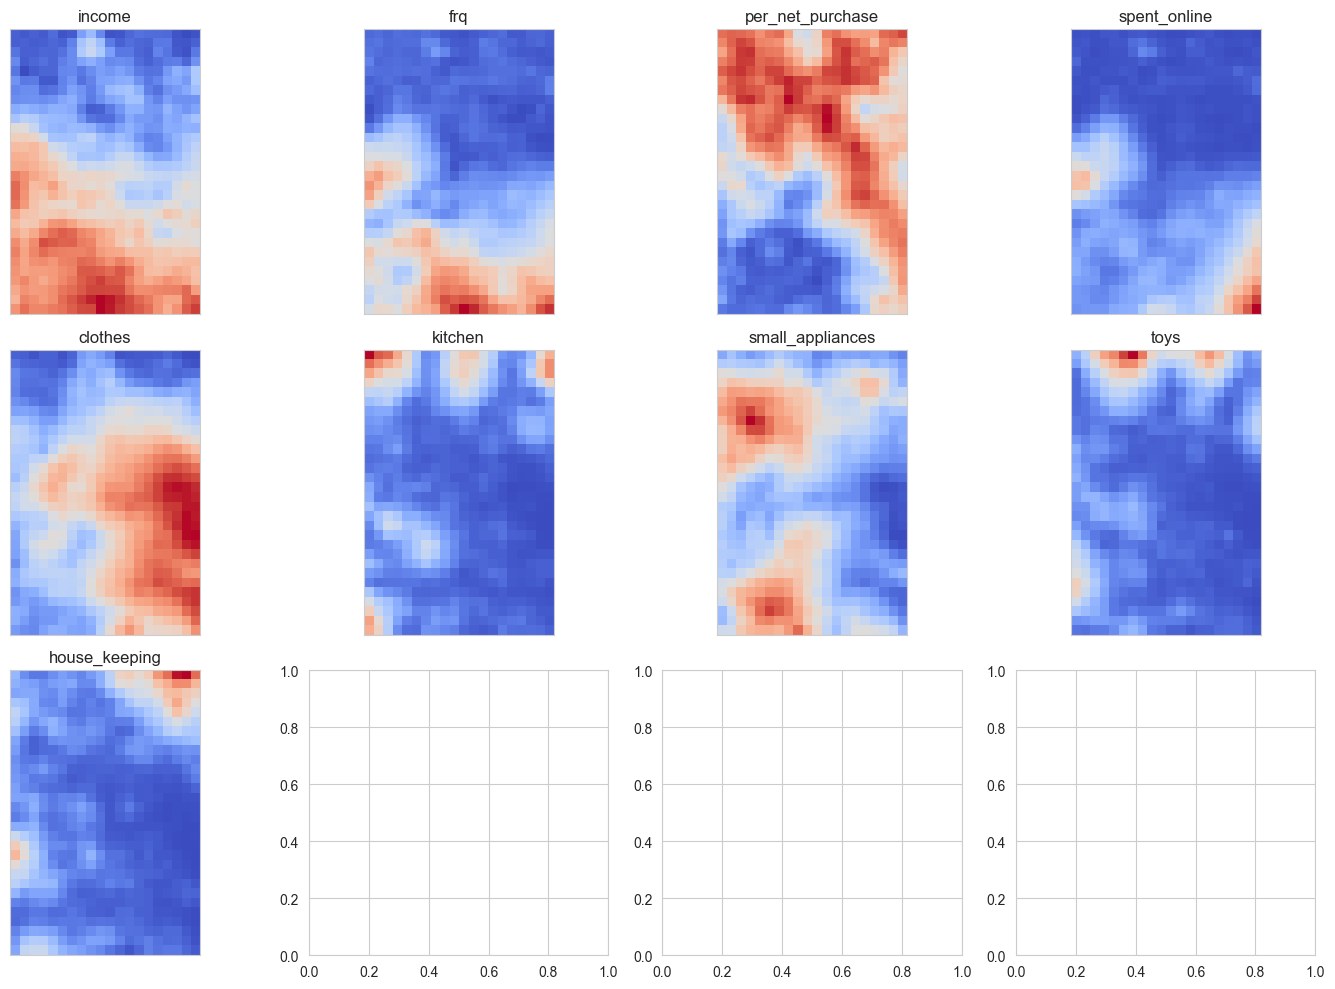

In [16]:
fig, axes = plt.subplots(3,4, figsize=(14,10))

for i, feature in enumerate(metric_features):
    ax = axes[i//4, i%4]
    plane = weights[:,:,i]
    im = ax.imshow(plane.T, cmap="coolwarm")
    ax.set_title(feature)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()